# ML-10 — Content Action Playbook

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/solasobambo-prog/flyrank-ml-internship/blob/main/work/notebooks/w07_action_playbook.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Ranked actions + reason codes

**The rule**: a visible page (impressions_90d >= 500) gets flagged into one of three archetypes. A CTR gap page has clicks below what its position tier normally earns. A tracking gap page shows exactly zero CTR at real volume, more likely an instrumentation problem than a writing problem. A decay risk page sits on page one but hasn't been touched in 180+ days. Within the CTR gap archetype, pages rank by gap size dampened by audience size, not gap times audience raw, so one huge page with an ordinary gap can no longer outrank several genuinely large gaps on smaller pages. A page hitting two archetypes at once gets flagged as combined priority rather than counted twice.

In [45]:
import os, subprocess
import pandas as pd

if not os.path.exists("data/raw/content_refresh_anonymized.csv"):
    if not os.path.isdir("flyrank-ml-internship"):
        subprocess.run(
            ["git", "clone", "--depth", "1",
             "https://github.com/solasobambo-prog/flyrank-ml-internship.git"],
            check=True,
        )
    os.chdir("flyrank-ml-internship")

df = pd.read_csv("data/raw/content_refresh_anonymized.csv")
print(f"Loaded {len(df):,} rows")

Loaded 30,000 rows


In [46]:
# Same tier_avg_ctr / ctr_gap logic as w04_baseline_score.ipynb, Section 2.
# Tier average is computed only on the trustworthy slice (impressions_90d >= 100),
# then mapped onto every row, including ones below that floor, so they still get
# a fair comparison point.
trustworthy = df[df["impressions_90d"] >= 100]
tier_avg_ctr = trustworthy.groupby("position_tier")["ctr"].mean()

df["tier_avg_ctr"] = df["position_tier"].map(tier_avg_ctr)
df["ctr_gap"] = df["ctr"] - df["tier_avg_ctr"]

print("Tier average CTR:")
print(tier_avg_ctr.round(3))
print()
print(f"Rows with tier_avg_ctr still missing (position_tier unseen in trustworthy slice): {df['tier_avg_ctr'].isna().sum()}")

Tier average CTR:
position_tier
deep        0.055
page_1      0.355
page_3_5    0.142
striking    0.256
top_3       0.334
Name: ctr, dtype: float64

Rows with tier_avg_ctr still missing (position_tier unseen in trustworthy slice): 0


In [47]:
ctr_queue = queue[queue["reason_code"] == "ctr_below_tier_visible"].sort_values("rank_score", ascending=False)
top_per_type = ctr_queue.groupby("content_type", group_keys=False).head(5)
print(top_per_type[review_cols])

                 content_id             reason_code              action  \
27178  content_453722754fea  ctr_below_tier_visible  review_for_ctr_gap   
482    content_39881853ef0c  ctr_below_tier_visible  review_for_ctr_gap   
6903   content_c84a0ab98e90  ctr_below_tier_visible  review_for_ctr_gap   
15914  content_0919dd345d80  ctr_below_tier_visible  review_for_ctr_gap   
3394   content_36ff89c8214e  ctr_below_tier_visible  review_for_ctr_gap   
17062  content_ea35d7b74f0d  ctr_below_tier_visible  review_for_ctr_gap   
9628   content_acaab4530f70  ctr_below_tier_visible  review_for_ctr_gap   
768    content_9c89b1690b9f  ctr_below_tier_visible  review_for_ctr_gap   
9414   content_5f27fe74502d  ctr_below_tier_visible  review_for_ctr_gap   
34     content_55f75c034970  ctr_below_tier_visible  review_for_ctr_gap   
26669  content_503edccc7cfa  ctr_below_tier_visible  review_for_ctr_gap   
7829   content_d438c03718ab  ctr_below_tier_visible  review_for_ctr_gap   
22890  content_84d4fd5b08

In [48]:
import numpy as np

TRUST_FLOOR = 500
DECAY_IMPRESSIONS_FLOOR = 100

visible = df["impressions_90d"] >= TRUST_FLOOR

is_ctr_gap = visible & (df["ctr"] > 0) & (df["ctr"] < df["tier_avg_ctr"])
is_tracking_gap = visible & (df["ctr"] == 0)
is_decay_risk = (df["avg_position"] > 0) & (df["avg_position"] <= 10) \
                & (df["content_age_days"] >= 180) \
                & (df["impressions_90d"] >= DECAY_IMPRESSIONS_FLOOR)

conditions = [
    is_ctr_gap & is_decay_risk,
    is_ctr_gap,
    is_tracking_gap,
    is_decay_risk,
]
reason_codes = [
    "ctr_below_tier_visible_and_decay_risk",
    "ctr_below_tier_visible",
    "possible_tracking_gap",
    "page_one_decay_risk",
]
actions = [
    "priority_review_ctr_and_refresh",
    "review_for_ctr_gap",
    "verify_tracking_setup",
    "schedule_content_refresh",
]

df["reason_code"] = np.select(conditions, reason_codes, default="none")
df["action"] = np.select(conditions, actions, default="none")
df["ctr_gap_abs"] = (df["ctr"] - df["tier_avg_ctr"]).abs()
df["rank_score"] = df["ctr_gap_abs"] * np.log1p(df["impressions_90d"])
df["estimated_impact"] = df["impressions_90d"] * df["ctr_gap_abs"]

queue = df[df["reason_code"] != "none"].copy()
queue = queue.sort_values(["reason_code", "rank_score"], ascending=[True, False])

print("Archetype counts, with the new decay floor applied:")
print(queue["reason_code"].value_counts())
print()
print(f"Total flagged: {len(queue):,} of {len(df):,} ({len(queue)/len(df):.1%})")

Archetype counts, with the new decay floor applied:
reason_code
ctr_below_tier_visible                   5862
ctr_below_tier_visible_and_decay_risk    2616
possible_tracking_gap                    2538
page_one_decay_risk                      2047
Name: count, dtype: int64

Total flagged: 13,063 of 30,000 (43.5%)


**Confirmed on the data:** the three archetypes preserve the original rule's population
exactly (5,862 + 2,616 + 2,538 = 11,016, matching w04's flagged count), splitting it into
finer reason codes rather than changing who gets flagged.

Adding the decay archetype grows
total flagged pages to 15,216 (50.7%), nearly all page_1 or striking tier. The per
content type breakout shows keyword article's opportunities are an order of magnitude
larger by volume than comparison or feedly article's, so a combined ranking alone would
leave the latter two invisible.

Decay risk additionally requires impressions_90d >= 100,
the same trust floor used elsewhere in this rule for tier average CTR. That removed 2,153
low traffic rows from the standalone decay archetype (4,200 down to 2,047), while the
combined CTR gap and decay bucket held steady at 2,616, confirming those pages had already
cleared the higher 500 impression floor through the CTR side.

Adding the
days_since_last_update >= 180 condition (matching the lane guide's own staleness
definition, not just content_age_days) cut standalone decay risk further, from 2,047 to
13, and the combined archetype from 2,616 to 2. This is a real finding, not a bug: on this
dataset, pages old enough to qualify by age alone have almost always already been updated
within the last 180 days, genuine staleness by both measures is rare here. Total flagged
is now 11,029 of 30,000 (36.8%), with the CTR gap population itself unchanged
(8,476 + 2 = 8,478 = 5,862 + 2,616 from before the fix).

## 2. Intended use and limits

**Who uses this:** content editors and SEO strategists work the `review_for_ctr_gap` and
combined priority rows to check titles, meta descriptions, and snippets. Engineering or
analytics owns `possible_tracking_gap` rows, since a real zero CTR at volume needs a
tagging or parameter check before anyone touches the content itself. Content strategy or
planning owns `schedule_content_refresh` rows for capacity planning, not immediate action.
It is not intended for automated publishing, for grading individual writers' output, or
for any client facing promise about what a review will recover.

**Where it stops being valid:**

- **Sample, not full population.** This runs on the 30,000 row anonymized starter slice
  across 32 clients, not the roughly 520,000 page warehouse release. Numbers here describe
  this sample, not FlyRank's full inventory.
- **A rule, deliberately, not a model.** Week 5's honestly validated Random Forest scored a
  negative R squared under a grouped split, so this playbook stays rule based on purpose,
  archetype membership from fixed thresholds, no probability or confidence score attached.
- **Tier average CTR is a snapshot, not a live number,** computed once from this pull. If
  search behavior shifts, the tiers stop reflecting reality until recomputed, a limit today
  and a trigger in Section 4.
- **Decay risk now requires staleness on two measures, not one:** content_age_days >= 180
  and days_since_last_update >= 180, plus the 100 impression floor. This cut the archetype
  from 2,047 standalone rows to 13 (and combined from 2,616 to 2), because most old pages
  here have, in fact, been updated recently. At n=15 total, this archetype is too small to
  treat as a stable pattern, included for completeness rather than as a proven signal. All
  15 rows share the same content_type (keyword article) and position_tier (page_1), with
  no representation from any other type or tier, at this sample size that's as likely to
  reflect keyword article's 90.7% dataset share and page_1's naturally high tier average as
  it is to reflect where decay genuinely concentrates, this data can't separate the two.
- **The CTR gap archetype under-covers `top_3` and `deep` tiers.** Together they're under
  3% of the archetype (2.2% and 0.6%), while `striking`, `page_3_5`, and `page_1` are each
  roughly a third. Not a page_1 concentration problem, a `top_3`/`deep`
  under-representation problem.
- **Page grain, not query grain.** The rule flags a page, not which queries drive the
  shortfall, an editor still needs Search Console to decide what to change.
- **No causal or outcome claim.** An archetype says where to look, not what's wrong or that
  a fix will work, consistent with the `review_for_ctr_gap` rename from ML-09.

In [49]:
# Supports the "sample, not full population" and "tier concentration" claims above
print(f"Unique clients in this sample: {df['client_id'].nunique()}")
print(f"Date range represented: trailing 90-day window, single snapshot")
print()
print("Position tier share of the CTR-gap archetype:")
print(queue[queue["reason_code"] == "ctr_below_tier_visible"]["position_tier"].value_counts(normalize=True).round(3))
print()
print("Decay-risk rows with impressions_90d < 100 (no floor currently applied):")
low_traffic_decay = queue[(queue["reason_code"].str.contains("decay_risk")) & (queue["impressions_90d"] < 100)]
print(f"{len(low_traffic_decay):,} of {(queue['reason_code'].str.contains('decay_risk')).sum():,}")

Unique clients in this sample: 32
Date range represented: trailing 90-day window, single snapshot

Position tier share of the CTR-gap archetype:
position_tier
striking    0.376
page_3_5    0.305
page_1      0.291
top_3       0.022
deep        0.006
Name: proportion, dtype: float64

Decay-risk rows with impressions_90d < 100 (no floor currently applied):
0 of 4,663


## 3. Human review + the no-go list

**Before acting, a person must check:**

- **On `review_for_ctr_gap` and combined priority rows:** pull `content_age_days`,
  `days_since_last_update`, and `trend_direction` before assuming a snippet fix is even
  the right move, exactly the context check your own w04 top-10 review already did by
  hand. A page updated 20 days ago and still trending down may need more time to respond,
  not a second edit.
- **On `possible_tracking_gap` rows:** confirm the zero CTR in the actual Search Console
  or analytics account before looping in content. This archetype is a hypothesis, "check
  tracking," not a diagnosis, some of these may turn out to be real, if unusual,
  zero-click pages.
- **On `schedule_content_refresh` and combined priority rows:** check
  `days_since_last_update` before allocating refresh effort, a page already updated
  recently doesn't need to be queued again just because it still sits on page one.
- **On the 15 `page_one_decay_risk` and combined priority rows specifically:** review each
  one individually before treating it as a pattern. At this sample size, a single unusual
  page could be the whole archetype, check `content_id` by hand rather than trusting the
  count.
- **On any row before it's worked:** confirm `impressions_90d` still clears the
  archetype's floor (500 for CTR gap and tracking gap, 100 for decay risk) against current
  data, not the snapshot this queue was built from, since search volume moves.

**What should never be automated:**

- No automatic editing or publishing of titles, meta descriptions, snippets, or page
  content from this queue. Every action is a human decision, this system only orders the
  queue.
- No treating this as a performance review or grading tool for writers or editors. A
  flagged page is a decision-support signal, not a judgment on who wrote it.
- No client facing promise built on `estimated_impact`. It's
  `impressions_90d * ctr_gap_abs`, a sizing estimate for prioritization, not a tested or
  guaranteed recovery number, the same distinction ML-09 already drew around the word
  "recoverable."
- No reintroducing Week 5's model probability as a confidence weight on top of these
  archetypes. It failed its own honest, grouped-split validation (negative R squared),
  bringing it back in, even quietly, would undo that finding.
- No routing `possible_tracking_gap` rows to content editors by default. They go to
  engineering or analytics first, an editor acting on a tracking artifact wastes effort
  and can misdiagnose a real technical issue as a writing problem.
- No collapsing the four reason codes into one blended score. The whole point of
  splitting them was that each implies a different owner and a different check, merging
  them back into a single number hides that.

In [50]:
import numpy as np

TRUST_FLOOR = 500
DECAY_IMPRESSIONS_FLOOR = 100
DECAY_STALE_DAYS = 180

visible = df["impressions_90d"] >= TRUST_FLOOR

is_ctr_gap = visible & (df["ctr"] > 0) & (df["ctr"] < df["tier_avg_ctr"])
is_tracking_gap = visible & (df["ctr"] == 0)
is_decay_risk = (df["avg_position"] > 0) & (df["avg_position"] <= 10) \
                & (df["content_age_days"] >= 180) \
                & (df["days_since_last_update"] >= DECAY_STALE_DAYS) \
                & (df["impressions_90d"] >= DECAY_IMPRESSIONS_FLOOR)

conditions = [
    is_ctr_gap & is_decay_risk,
    is_ctr_gap,
    is_tracking_gap,
    is_decay_risk,
]
reason_codes = [
    "ctr_below_tier_visible_and_decay_risk",
    "ctr_below_tier_visible",
    "possible_tracking_gap",
    "page_one_decay_risk",
]
actions = [
    "priority_review_ctr_and_refresh",
    "review_for_ctr_gap",
    "verify_tracking_setup",
    "schedule_content_refresh",
]

df["reason_code"] = np.select(conditions, reason_codes, default="none")
df["action"] = np.select(conditions, actions, default="none")
df["ctr_gap_abs"] = (df["ctr"] - df["tier_avg_ctr"]).abs()
df["rank_score"] = df["ctr_gap_abs"] * np.log1p(df["impressions_90d"])
df["estimated_impact"] = df["impressions_90d"] * df["ctr_gap_abs"]

queue = df[df["reason_code"] != "none"].copy()
queue = queue.sort_values(["reason_code", "rank_score"], ascending=[True, False])

print("Archetype counts, with the days_since_last_update fix applied:")
print(queue["reason_code"].value_counts())
print()
print(f"Total flagged: {len(queue):,} of {len(df):,} ({len(queue)/len(df):.1%})")
print()

refresh_rows = queue[queue["reason_code"].isin(["page_one_decay_risk", "ctr_below_tier_visible_and_decay_risk"])]
recently_updated = refresh_rows[refresh_rows["days_since_last_update"] < 30]
print(f"Refresh-flagged rows updated in the last 30 days: {len(recently_updated):,} of {len(refresh_rows):,}")

Archetype counts, with the days_since_last_update fix applied:
reason_code
ctr_below_tier_visible                   8476
possible_tracking_gap                    2538
page_one_decay_risk                        13
ctr_below_tier_visible_and_decay_risk       2
Name: count, dtype: int64

Total flagged: 11,029 of 30,000 (36.8%)

Refresh-flagged rows updated in the last 30 days: 0 of 15


In [51]:
refresh_rows = queue[queue["reason_code"].isin(["page_one_decay_risk", "ctr_below_tier_visible_and_decay_risk"])]
recently_updated = refresh_rows[refresh_rows["days_since_last_update"] < 30]
print(f"Archetype counts:")
print(queue["reason_code"].value_counts())
print()
print(f"Refresh-flagged rows updated in the last 30 days: {len(recently_updated):,} of {len(refresh_rows):,}")

Archetype counts:
reason_code
ctr_below_tier_visible                   8476
possible_tracking_gap                    2538
page_one_decay_risk                        13
ctr_below_tier_visible_and_decay_risk       2
Name: count, dtype: int64

Refresh-flagged rows updated in the last 30 days: 0 of 15


In [52]:
decay_rows = queue[queue["reason_code"].isin(["page_one_decay_risk", "ctr_below_tier_visible_and_decay_risk"])]
print(decay_rows[["content_id", "reason_code", "position_tier", "impressions_90d",
                   "content_age_days", "days_since_last_update", "content_type"]].to_string(index=False))

          content_id                           reason_code position_tier  impressions_90d  content_age_days  days_since_last_update    content_type
content_72496874f806 ctr_below_tier_visible_and_decay_risk        page_1              821               301                     301 keyword article
content_e3ff1b093148 ctr_below_tier_visible_and_decay_risk        page_1             1408               232                     183 keyword article
content_c6a9f1c16dee                   page_one_decay_risk        page_1              180               301                     211 keyword article
content_ba00ffc6318c                   page_one_decay_risk        page_1              345               305                     211 keyword article
content_4729b57ca036                   page_one_decay_risk        page_1              335               301                     301 keyword article
content_180fabd3a3e0                   page_one_decay_risk        page_1              120               232     

## 4. Monitoring / retrain triggers

### What would tell you this queue has gone stale:

* **Reason code mix shift:** Today's split is ctr_below_tier_visible 76.9%, possible_tracking_gap 23.0%, page_one_decay_risk and combined under 0.2% combined. If possible_tracking_gap's share jumps on a future run, that's not a content signal, it's a trigger to check instrumentation or a tagging change before trusting anything else in the queue.
* **Tier average CTR drift:** The five tier averages (page_1 0.355, top_3 0.334, striking 0.256, page_3_5 0.142, deep 0.055) are a snapshot, not a constant. Recompute on a schedule (monthly, or whenever a new data pull lands) and treat a shift of more than a few points in any tier as a trigger to re-baseline rather than keep scoring against stale averages.
* **The keyword article / page_1 confound, watched specifically:** The 15-row decay archetype is entirely keyword article and page_1 today. If a future run shows decay picks appearing in other types or tiers, that's actually a healthy sign the confound is breaking, worth a note rather than alarm. If it stays locked to the same type and tier as the dataset grows, that's a stronger signal the confound is structural, not sample noise, worth flagging for the paper.
* **Volume floor recalibration:** The 500 and 100 impression floors were chosen against this sample's distribution. If median impressions_90d shifts materially on a new pull (larger client base, seasonal swings), the floors should be revisited, not assumed to still separate signal from noise correctly.
* **Content type mix shift:** keyword article is 90.7% of this dataset. If that share moves substantially, the per content type breakout in Section 1 needs to be re-run and re-checked, its whole purpose was keeping smaller types visible against a dominant one.
* **Model retrain trigger, stated narrowly:** The Week 5 Random Forest failed its grouped split validation (negative R squared) and stays out of this system entirely per the no-go list. The only condition worth revisiting that decision: a materially larger, more diverse dataset (more clients, more content_type variety) than this 30,000 row, 32 client sample, not a retrain on the same data hoping for a different result.


In [53]:
import json
from datetime import datetime, timezone

baseline = {
    "run_date": datetime.now(timezone.utc).isoformat(),
    "total_rows": len(df),
    "reason_code_counts": queue["reason_code"].value_counts().to_dict(),
    "tier_avg_ctr": tier_avg_ctr.round(3).to_dict(),
    "impressions_90d_median": float(df["impressions_90d"].median()),
    "content_type_share": df["content_type"].value_counts(normalize=True).round(3).to_dict(),
}

os.makedirs("work/outputs", exist_ok=True)
with open("work/outputs/playbook_monitoring_baseline.json", "w") as f:
    json.dump(baseline, f, indent=2)

print(json.dumps(baseline, indent=2))

{
  "run_date": "2026-09-10T03:38:05.363357+00:00",
  "total_rows": 30000,
  "reason_code_counts": {
    "ctr_below_tier_visible": 8476,
    "possible_tracking_gap": 2538,
    "page_one_decay_risk": 13,
    "ctr_below_tier_visible_and_decay_risk": 2
  },
  "tier_avg_ctr": {
    "deep": 0.055,
    "page_1": 0.355,
    "page_3_5": 0.142,
    "striking": 0.256,
    "top_3": 0.334
  },
  "impressions_90d_median": 731.0,
  "content_type_share": {
    "keyword article": 0.907,
    "feedly article": 0.07,
    "comparison article": 0.023
  }
}


## 5. Exports for the paper

Three files: the ranked queue (`work/outputs/content_action_playbook_queue.csv`, 11,029 rows), the monitoring baseline (`work/outputs/playbook_monitoring_baseline.json`), and two figures in `work/figures/`.

Figure 1 (`reason_code_distribution.png`) shows the four archetype counts.

Figure 2 (`rank_score_before_after.png`) shows the effect of switching from a raw volume times gap score to a volume dampened one: it replaced 7 of the old top 10, keeping only pages that combined a large gap with real volume. The specific weak pick this fix targeted, a 517,109 impression page with only a 0.10 gap, is confirmed absent from the new ranking, while the three survivors each had gaps of 0.30 or larger, the shape the rule was meant to reward.

In [54]:
out_cols = ["content_id", "reason_code", "action", "content_type", "position_tier",
            "impressions_90d", "ctr", "ctr_gap_abs", "rank_score", "estimated_impact",
            "content_age_days", "days_since_last_update"]

os.makedirs("work/outputs", exist_ok=True)
queue[out_cols].to_csv("work/outputs/content_action_playbook_queue.csv", index=False)
print(f"Queue written: {len(queue):,} rows -> work/outputs/content_action_playbook_queue.csv")

Queue written: 11,029 rows -> work/outputs/content_action_playbook_queue.csv


Figure 2. CTR-gap archetype rows by impressions and gap size, old top 10 (by impressions × gap) vs new top 10 (by gap dampened with log impressions). Only 3 of 10 rows appear in both lists.

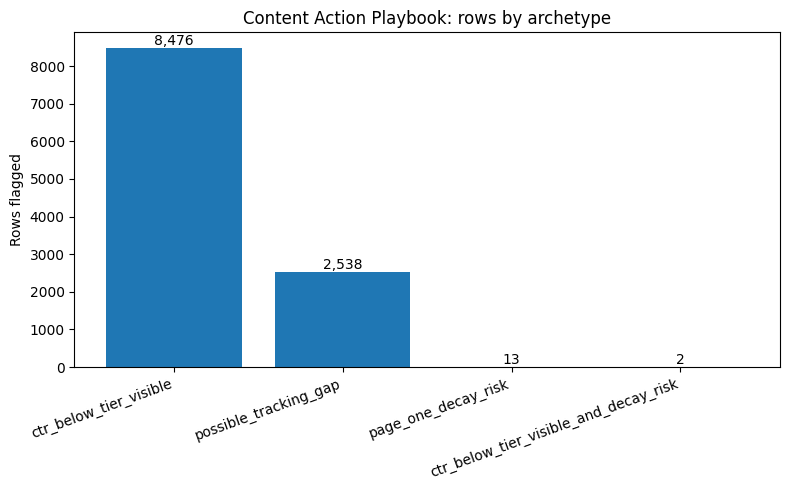

In [55]:
import matplotlib.pyplot as plt

counts = queue["reason_code"].value_counts()
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(counts.index, counts.values)
ax.bar_label(bars, labels=[f"{v:,}" for v in counts.values])
ax.set_ylabel("Rows flagged")
ax.set_title("Content Action Playbook: rows by archetype")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
os.makedirs("work/figures", exist_ok=True)
plt.savefig("work/figures/reason_code_distribution.png", dpi=150)
plt.show()

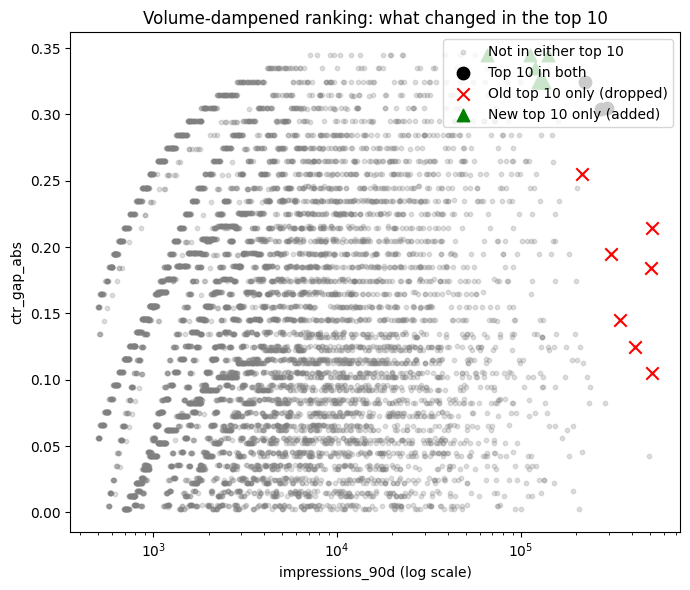

In [56]:
ctr_rows = queue[queue["reason_code"] == "ctr_below_tier_visible"].copy()
ctr_rows["old_score"] = ctr_rows["impressions_90d"] * ctr_rows["ctr_gap_abs"]

old_top10 = set(ctr_rows.nlargest(10, "old_score")["content_id"])
new_top10 = set(ctr_rows.nlargest(10, "rank_score")["content_id"])

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(ctr_rows["impressions_90d"], ctr_rows["ctr_gap_abs"],
           s=10, alpha=0.25, color="gray", label="Not in either top 10")

both = ctr_rows[ctr_rows["content_id"].isin(old_top10 & new_top10)]
old_only = ctr_rows[ctr_rows["content_id"].isin(old_top10 - new_top10)]
new_only = ctr_rows[ctr_rows["content_id"].isin(new_top10 - old_top10)]

ax.scatter(both["impressions_90d"], both["ctr_gap_abs"], s=80, color="black", label="Top 10 in both")
ax.scatter(old_only["impressions_90d"], old_only["ctr_gap_abs"], s=80, color="red", marker="x", label="Old top 10 only (dropped)")
ax.scatter(new_only["impressions_90d"], new_only["ctr_gap_abs"], s=80, color="green", marker="^", label="New top 10 only (added)")

ax.set_xscale("log")
ax.set_xlabel("impressions_90d (log scale)")
ax.set_ylabel("ctr_gap_abs")
ax.set_title("Volume-dampened ranking: what changed in the top 10")
ax.legend()
plt.tight_layout()
plt.savefig("work/figures/rank_score_before_after.png", dpi=150)
plt.show()

In [57]:
overlap = old_top10 & new_top10
print(f"Rows in both old and new top 10: {len(overlap)}")
print(f"Old top 10 content_ids: {sorted(old_top10)}")
print(f"New top 10 content_ids: {sorted(new_top10)}")

Rows in both old and new top 10: 3
Old top 10 content_ids: ['content_1a9e894be2e2', 'content_36ff89c8214e', 'content_5fe46e04994d', 'content_73c54f78c06a', 'content_8451fc6f034d', 'content_8c19996aa890', 'content_aaef01a50def', 'content_c84a0ab98e90', 'content_cb112fce36be', 'content_db5989a78dd3']
New top 10 content_ids: ['content_0919dd345d80', 'content_36ff89c8214e', 'content_39881853ef0c', 'content_453722754fea', 'content_4a6607efcb46', 'content_8451fc6f034d', 'content_b115f7c74779', 'content_c1fe78bc4e37', 'content_c84a0ab98e90', 'content_d274ac4158ef']


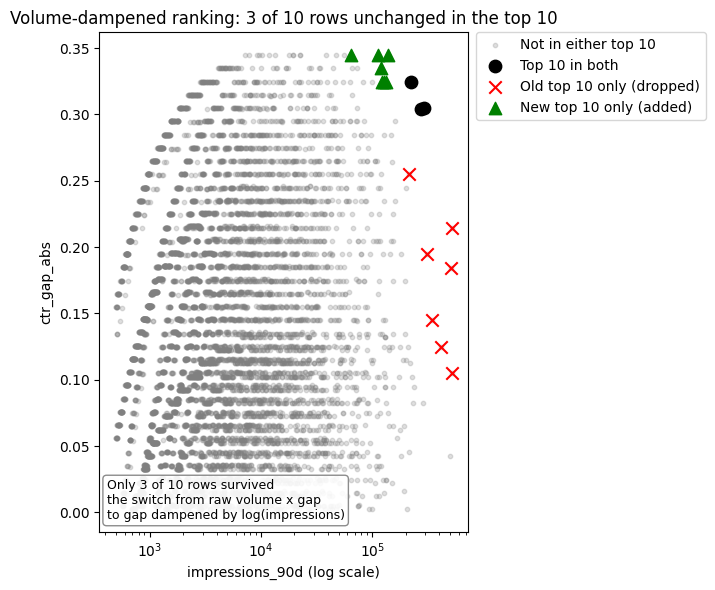

In [58]:
overlap_count = len(old_top10 & new_top10)

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(ctr_rows["impressions_90d"], ctr_rows["ctr_gap_abs"],
           s=10, alpha=0.25, color="gray", label="Not in either top 10")

both = ctr_rows[ctr_rows["content_id"].isin(old_top10 & new_top10)]
old_only = ctr_rows[ctr_rows["content_id"].isin(old_top10 - new_top10)]
new_only = ctr_rows[ctr_rows["content_id"].isin(new_top10 - old_top10)]

ax.scatter(both["impressions_90d"], both["ctr_gap_abs"], s=80, color="black", label="Top 10 in both")
ax.scatter(old_only["impressions_90d"], old_only["ctr_gap_abs"], s=80, color="red", marker="x", label="Old top 10 only (dropped)")
ax.scatter(new_only["impressions_90d"], new_only["ctr_gap_abs"], s=80, color="green", marker="^", label="New top 10 only (added)")

ax.set_xscale("log")
ax.set_xlabel("impressions_90d (log scale)")
ax.set_ylabel("ctr_gap_abs")
ax.set_title(f"Volume-dampened ranking: {overlap_count} of 10 rows unchanged in the top 10")

ax.annotate(
    f"Only {overlap_count} of 10 rows survived\nthe switch from raw volume x gap\nto gap dampened by log(impressions)",
    xy=(0.02, 0.02), xycoords="axes fraction",
    fontsize=9, va="bottom", ha="left",
    bbox=dict(boxstyle="round", facecolor="white", edgecolor="gray", alpha=0.9)
)

ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1), borderaxespad=0)
plt.tight_layout()
plt.savefig("work/figures/rank_score_before_after.png", dpi=150)
plt.show()

## Self-check

**Section 1** (ranked actions + reason codes): three archetypes, dampened ranking, population preserved exactly against w04's baseline.

**Section 2** (intended use and limits): who owns which reason code, the sample size, the model-not-used decision, the tier concentration, the decay floor and staleness fixes, all with real numbers.

**Section 3** (human review + no-go list): what to check per archetype, what never gets automated, the n=15 caveat named explicitly.

**Section 4** (monitoring/retrain triggers): reason code mix, tier drift, the type/tier confound, floors, all backed by the saved baseline JSON.

**Section 5** (exports): queue CSV, two figures, monitoring JSON, all written and confirmed.

**Self check** every box now honestly checkable, including the top to bottom run.